In [28]:
import uproot
import pandas as pd

chunks = []

with uproot.open("~/Scrivania/sampic_run51_merged.root") as file:
    tree = file["picoTree"]
    
    # Prima vediamo cosa c'è nel tree
    print("Branch disponibili:")
    print(tree.keys())
    print(f"\nNumero totale di eventi: {tree.num_entries}")

Branch disponibili:
['Detector', 'Feb', 'Multiplicity', 'Channel', 'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue', 'Baseline', 'Waveform', 'Amplitude', 'ArraySize', 'xCoord', 'yCoord', 'Davide', 'Golia', '7PAD', 'MCP']

Numero totale di eventi: 638043


In [29]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd

branch_list = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'ArraySize',
    'xCoord', 'yCoord', 'Davide', 'Golia', '7PAD', 'MCP'
]

branch_2d = [
    'Detector', 'Feb', 'Multiplicity', 'Channel',
    'Cell0TimeStamp', 'TimeInstant', 'TOTValue', 'PeakValue',
    'Baseline', 'Amplitude', 'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open("~/Scrivania/sampic_run51_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=50_000)):
        n_chunk = len(chunk)

        # ArraySize dice esattamente quante hit valide ci sono per evento
        array_size = ak.to_numpy(chunk['ArraySize'])  # shape (n_chunk,)

        # --- Branch 2D: taglia ogni riga a ArraySize invece di usare maschera -1 ---
        arr_2d = {k: ak.to_numpy(chunk[k]) for k in branch_2d}

        rows_2d = {k: [] for k in branch_2d}
        for evt in range(n_chunk):
            n_hit = array_size[evt]
            for k in branch_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])

        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in branch_2d})

        # --- Branch 1D: ripeti per ogni hit dell'evento ---
        arr_1d = {k: ak.to_numpy(chunk[k]) for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size) for k in branch_1d})

        # --- Multiplicity: estrai le 3 posizioni come colonne separate ---
        mult = ak.to_numpy(chunk['Multiplicity'])  # shape (n_chunk, 140)
        df_mult_per_evento = pd.DataFrame({
            'Mult_det0': mult[:, 0],
            'Mult_det1': mult[:, 1],
            'Mult_det2': mult[:, 2],
        })
        # Ripeti per ogni hit dell'evento
        df_mult = pd.DataFrame({
            col: np.repeat(df_mult_per_evento[col].values, array_size)
            for col in df_mult_per_evento.columns
        })

        # --- Indice evento ---
        event_idx = np.repeat(np.arange(i * 50_000, i * 50_000 + n_chunk), array_size)

        # --- Assembla ---
        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        # Rimuovi Multiplicity grezza (era 2D, ora abbiamo le 3 colonne separate)
        df_chunk.drop(columns=['Multiplicity'], inplace=True)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi: {n_chunk} — hit totali: {len(df_chunk)} — letti: {min((i+1)*50_000, n_tot)}/{n_tot}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(10))

Chunk 1 — eventi: 50000 — hit totali: 93499 — letti: 50000/638043
Chunk 2 — eventi: 50000 — hit totali: 72236 — letti: 100000/638043
Chunk 3 — eventi: 50000 — hit totali: 68193 — letti: 150000/638043
Chunk 4 — eventi: 50000 — hit totali: 75496 — letti: 200000/638043
Chunk 5 — eventi: 50000 — hit totali: 75299 — letti: 250000/638043
Chunk 6 — eventi: 50000 — hit totali: 66798 — letti: 300000/638043
Chunk 7 — eventi: 50000 — hit totali: 74427 — letti: 350000/638043
Chunk 8 — eventi: 50000 — hit totali: 67345 — letti: 400000/638043
Chunk 9 — eventi: 50000 — hit totali: 74660 — letti: 450000/638043
Chunk 10 — eventi: 50000 — hit totali: 74350 — letti: 500000/638043
Chunk 11 — eventi: 50000 — hit totali: 67146 — letti: 550000/638043
Chunk 12 — eventi: 50000 — hit totali: 67966 — letti: 600000/638043
Chunk 13 — eventi: 38043 — hit totali: 54899 — letti: 638043/638043

✅ DataFrame finale: (932314, 20)
   event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  TOTValue  \
0          0

In [30]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd

# --- Parametri modificabili ---
X_TARGET = 5.0
Y_TARGET = 5.0

# Molteplicità per ogni detector — cambia solo questi!
MULT_DET0 = 1   # minimo hit detector 0
MULT_DET1 = 1   # minimo hit detector 1
MULT_DET2 = 0   # detector 2: whatever (0 = nessun vincolo)

# ------------------------------

branch_list = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude', 'Waveform',
    'ArraySize', 'xCoord', 'yCoord', 'Multiplicity',
    'Davide', 'Golia', '7PAD', 'MCP'
]

branch_2d = [
    'Detector', 'Feb', 'Channel', 'Cell0TimeStamp', 'TimeInstant',
    'TOTValue', 'PeakValue', 'Baseline', 'Amplitude',
    'xCoord', 'yCoord'
]

branch_1d = ['ArraySize', 'Davide', 'Golia', '7PAD', 'MCP']

chunks = []

with uproot.open("~/Scrivania/sampic_run51_merged.root") as file:
    tree = file["picoTree"]
    n_tot = tree.num_entries

    for i, chunk in enumerate(tree.iterate(branch_list, library="ak", step_size=50_000)):
        n_chunk = len(chunk)

        array_size = ak.to_numpy(chunk['ArraySize'])     # (n_chunk,)
        mult       = ak.to_numpy(chunk['Multiplicity'])  # (n_chunk, 140)

        # xCoord e yCoord sono uguali per tutte le hit dell'evento, prendi la prima
        xcoord = ak.to_numpy(chunk['xCoord'])[:, 0]
        ycoord = ak.to_numpy(chunk['yCoord'])[:, 0]

        # --- Filtro evento ---
        mask_evento = (
            (xcoord == X_TARGET) &
            (ycoord == Y_TARGET) &
            (mult[:, 0] == MULT_DET0) &
            (mult[:, 1] == MULT_DET1) &
            (mult[:, 2] >= MULT_DET2)   # se MULT_DET2=0 è sempre True
        )

        if mask_evento.sum() == 0:
            continue

        n_sel = mask_evento.sum()
        array_size_filt = array_size[mask_evento]
        mult_filt       = mult[mask_evento]

        # --- Branch 2D ---
        arr_2d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_2d}
        rows_2d = {k: [] for k in arr_2d}
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for k in arr_2d:
                rows_2d[k].append(arr_2d[k][evt, :n_hit])
        df_2d = pd.DataFrame({k: np.concatenate(rows_2d[k]) for k in arr_2d})

        # --- Waveform ---
        waveform_raw = ak.to_numpy(chunk['Waveform'])[mask_evento]
        waveforms = []
        for evt in range(n_sel):
            n_hit = array_size_filt[evt]
            for hit in range(n_hit):
                waveforms.append(waveform_raw[evt, hit, :])
        df_2d['Waveform'] = waveforms

        # --- Branch 1D ---
        arr_1d = {k: ak.to_numpy(chunk[k])[mask_evento] for k in branch_1d}
        df_1d = pd.DataFrame({k: np.repeat(arr_1d[k], array_size_filt) for k in branch_1d})

        # --- Multiplicity come colonne separate ---
        df_mult = pd.DataFrame({
            'Mult_det0': np.repeat(mult_filt[:, 0], array_size_filt),
            'Mult_det1': np.repeat(mult_filt[:, 1], array_size_filt),
            'Mult_det2': np.repeat(mult_filt[:, 2], array_size_filt),
        })

        # --- Indice evento originale ---
        idx_originali = np.where(mask_evento)[0] + i * 50_000
        event_idx = np.repeat(idx_originali, array_size_filt)

        df_chunk = pd.concat([
            pd.Series(event_idx, name='event_idx'),
            df_2d.reset_index(drop=True),
            df_1d.reset_index(drop=True),
            df_mult.reset_index(drop=True)
        ], axis=1)

        chunks.append(df_chunk)
        print(f"Chunk {i+1} — eventi selezionati: {n_sel} — hit totali: {len(df_chunk)}")

df = pd.concat(chunks, ignore_index=True)
print(f"\n✅ DataFrame finale: {df.shape}")
print(df.head(5))

Chunk 2 — eventi selezionati: 54 — hit totali: 110
Chunk 3 — eventi selezionati: 60 — hit totali: 122
Chunk 4 — eventi selezionati: 96 — hit totali: 193
Chunk 5 — eventi selezionati: 81 — hit totali: 164
Chunk 6 — eventi selezionati: 56 — hit totali: 113
Chunk 7 — eventi selezionati: 74 — hit totali: 149
Chunk 8 — eventi selezionati: 59 — hit totali: 118
Chunk 9 — eventi selezionati: 82 — hit totali: 164
Chunk 10 — eventi selezionati: 75 — hit totali: 150
Chunk 11 — eventi selezionati: 65 — hit totali: 130
Chunk 12 — eventi selezionati: 56 — hit totali: 114
Chunk 13 — eventi selezionati: 65 — hit totali: 130

✅ DataFrame finale: (1657, 21)
   event_idx  Detector  Feb  Channel  Cell0TimeStamp   TimeInstant  TOTValue  \
0      77044       2.0    1       45    1.337558e+11  1.337558e+11       0.0   
1      77044       1.0    3       45    1.337558e+11  1.337558e+11       0.0   
2      77263       2.0    1       45    1.337586e+11  1.337586e+11       0.0   
3      77263       1.0    3     

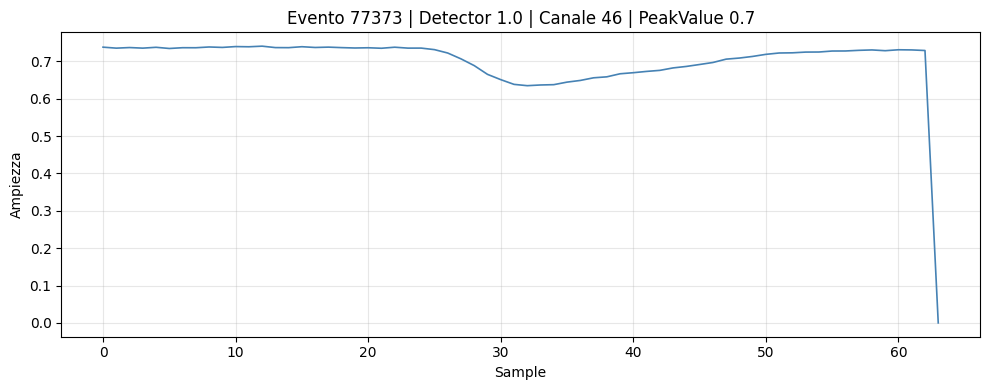

In [31]:
#singola waveform esempio
import matplotlib.pyplot as plt
import numpy as np

def plot_waveform(df, idx, colonna_tempo=None):
    """
    idx = indice della riga nel DataFrame (non event_idx!)
    """
    riga = df.iloc[idx]
    wf = riga['Waveform']
    
    x = np.arange(len(wf)) if colonna_tempo is None else colonna_tempo
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, wf, color='steelblue', lw=1.2)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Ampiezza")
    ax.set_title(
        f"Evento {riga['event_idx']} | "
        f"Detector {riga['Detector']} | "
        f"Canale {riga['Channel']} | "
        f"PeakValue {riga['PeakValue']:.1f}"
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Esempio: plotta la prima waveform
plot_waveform(df, idx=5)

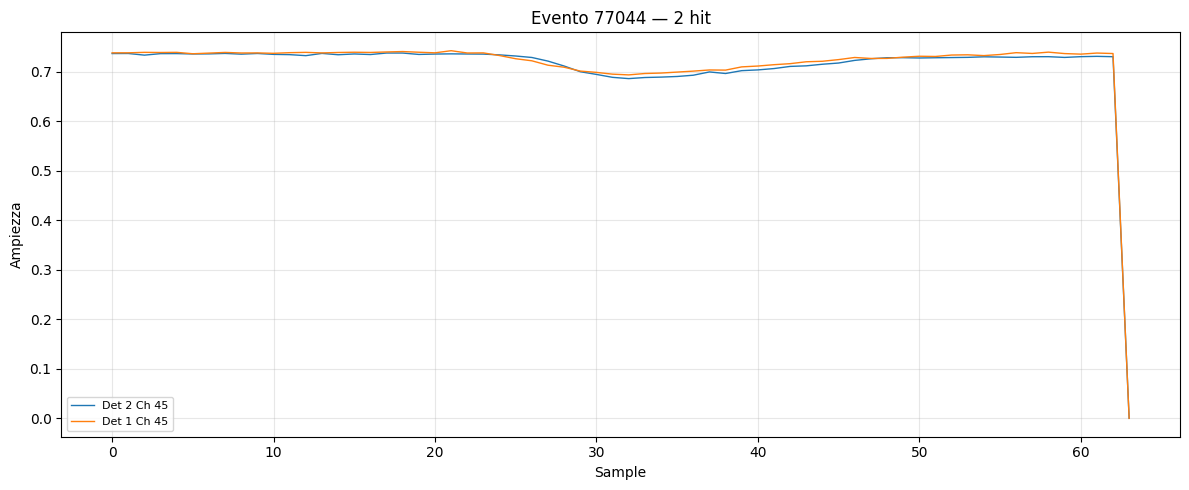

In [32]:
#tutte waveform per evento
def plot_evento(df, event_idx):
    """Plotta tutte le hit di un evento sullo stesso grafico"""
    righe = df[df['event_idx'] == event_idx]
    
    fig, ax = plt.subplots(figsize=(12, 5))
    for _, riga in righe.iterrows():
        ax.plot(riga['Waveform'], lw=1, label=f"Det {int(riga['Detector'])} Ch {int(riga['Channel'])}")
    
    ax.set_xlabel("Sample")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"Evento {event_idx} — {len(righe)} hit")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Esempio
plot_evento(df, event_idx=df['event_idx'].iloc[0])

In [33]:
#sample corrotto 
# Rimuove il sample 63 da ogni waveform
df['Waveform'] = df['Waveform'].apply(lambda wf: np.delete(wf, 63))

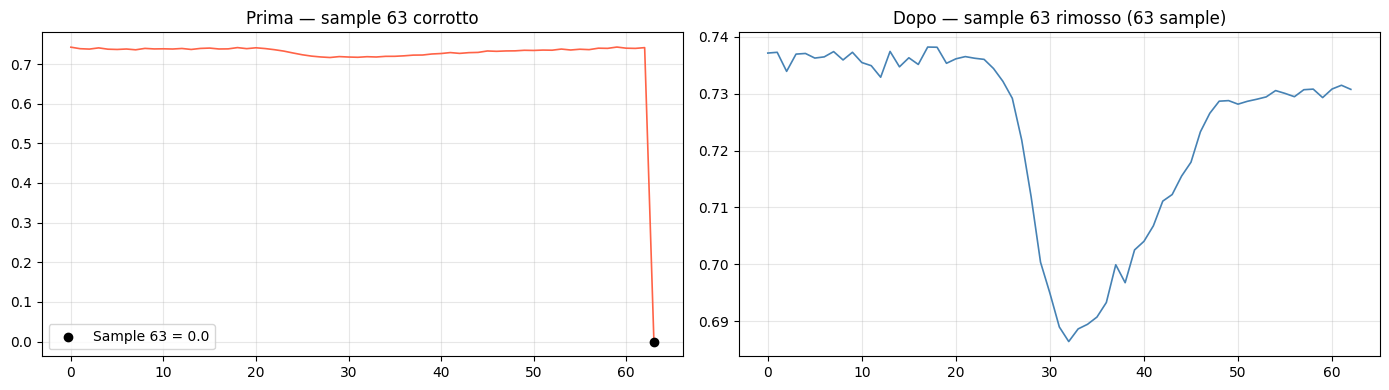

In [34]:
# Rileggiti la waveform originale dal file per il confronto
with uproot.open("~/Scrivania/sampic_run51_merged.root") as file:
    tree = file["picoTree"]
    wf_originale = tree['Waveform'].array(library="np", entry_start=0, entry_stop=1)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Prima: waveform originale con sample 63 evidenziato ---
axes[0].plot(wf_originale, color='tomato', lw=1.2)
axes[0].scatter(63, wf_originale[63], color='black', zorder=5, label=f'Sample 63 = {wf_originale[63]:.1f}')
axes[0].set_title("Prima — sample 63 corrotto")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Dopo: waveform pulita (sample 63 rimosso, ora ha n-1 punti) ---
wf_pulita = df['Waveform'].iloc[0]
axes[1].plot(wf_pulita, color='steelblue', lw=1.2)
axes[1].set_title(f"Dopo — sample 63 rimosso ({len(wf_pulita)} sample)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



   event_idx  Channel  Detector  integrale  ampiezza  rise_time  fwhm
0      77044       45       2.0  -0.805117 -0.050069        5.0  14.0
1      77044       45       1.0  -0.697196 -0.044626        7.0  15.0
2      77263       45       2.0  -0.555627 -0.032172       12.0  16.0
3      77263       45       1.0  -0.441494 -0.024426        NaN  19.0
4      77373       45       2.0  -0.563340 -0.033130       19.0  15.0
5      77373       46       1.0  -1.639965 -0.101780        5.0  15.0
6      77427       45       2.0  -0.410674 -0.026705        5.0  14.0
7      77427       45       1.0  -3.466495 -0.167553        6.0  17.0
8      77486       45       1.0  -1.461513 -0.083219        5.0  16.0
9      77486       45       2.0  -0.194860 -0.014658       19.0  13.0


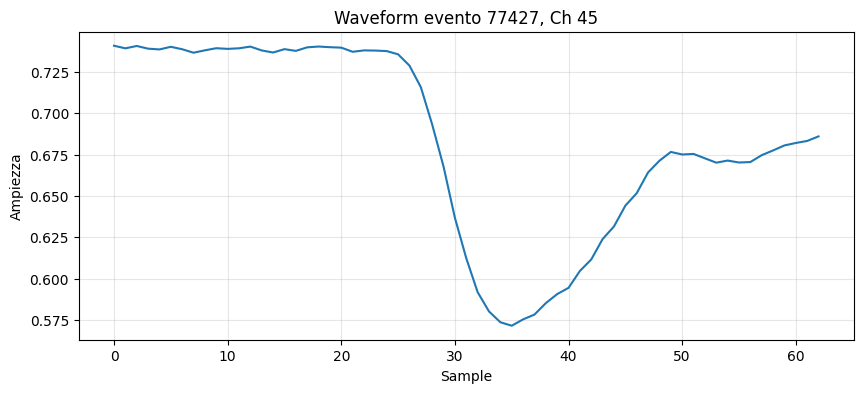

Min: 0.5715206
Max: 0.74077743
Media primi 10 sample (baseline): 0.7390734


In [35]:
def analizza_waveform(wf, n_baseline=10):
    """
    n_baseline = quante sample iniziali usare per stimare la baseline
    """
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = wf - baseline  # segnale centrato a zero

    # --- Picco (minimo perché segnale negativo) ---
    idx_picco = np.argmin(wf_corr)
    ampiezza  = np.min(wf_corr)  # valore negativo

    # --- Integrale (carica) ---
    integrale = np.trapezoid(wf_corr)  # sarà negativo

    # --- Tempo di salita (10% → 90% del picco, andando verso il basso) ---
    soglia_10 = 0.10 * ampiezza  # es. -10% del minimo
    soglia_90 = 0.90 * ampiezza  # es. -90% del minimo
    try:
        t10 = np.where(wf_corr[:idx_picco] <= soglia_10)[0][0]
        t90 = np.where(wf_corr[:idx_picco] <= soglia_90)[0][0]
        rise_time = t90 - t10
    except IndexError:
        rise_time = np.nan

    # --- FWHM ---
    soglia_half = 0.50 * ampiezza
    try:
        t_left  = np.where(wf_corr[:idx_picco] <= soglia_half)[0][0]
        t_right = idx_picco + np.where(wf_corr[idx_picco:] >= soglia_half)[0][0]
        fwhm = t_right - t_left
    except IndexError:
        fwhm = np.nan

    return {
        'baseline'  : baseline,
        'integrale' : integrale,
        'ampiezza'  : ampiezza,
        'idx_picco' : idx_picco,
        'rise_time' : rise_time,
        'fwhm'      : fwhm,
    }

# Applica a tutto il DataFrame
features = df['Waveform'].apply(analizza_waveform)
df_feat  = pd.DataFrame(features.tolist())
df       = pd.concat([df.reset_index(drop=True), df_feat], axis=1)

print(df[['event_idx', 'Channel', 'Detector', 'integrale', 'ampiezza', 'rise_time', 'fwhm']].head(10))

plt.figure(figsize=(10,4))
plt.plot(df['Waveform'].iloc[7])  # uso iloc[7] che ha ampiezza più grande
plt.grid(True, alpha=0.3)
plt.ylabel("Ampiezza")
plt.xlabel("Sample")
plt.title(f"Waveform evento {df['event_idx'].iloc[7]}, Ch {int(df['Channel'].iloc[7])}")
plt.show()

print("Min:", df['Waveform'].iloc[7].min())
print("Max:", df['Waveform'].iloc[7].max())
print("Media primi 10 sample (baseline):", df['Waveform'].iloc[7][:10].mean())

In [36]:
#pile up

from scipy.signal import find_peaks

def is_pileup(wf, n_baseline=10, soglia_relativa=0.3):
    """
    Inverte il segnale per find_peaks (che cerca massimi)
    soglia_relativa: abbassala se non trova pile-up, alzala se ne trova troppi
    """
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = -(wf - baseline)  # inverti: i minimi diventano massimi

    ampiezza_max = np.max(wf_corr)
    soglia       = soglia_relativa * ampiezza_max

    picchi, _ = find_peaks(wf_corr, height=soglia, distance=10)

    return len(picchi) > 1, len(picchi)

risultati      = df['Waveform'].apply(lambda wf: is_pileup(wf, soglia_relativa=0.3))
df['is_pileup'] = [r[0] for r in risultati]
df['n_picchi']  = [r[1] for r in risultati]

df_buoni  = df[~df['is_pileup']].reset_index(drop=True)
df_pileup = df[ df['is_pileup']].reset_index(drop=True)

print(f"✅ Eventi buoni : {len(df_buoni)}")
print(f"⚠️  Pile-up     : {len(df_pileup)}")
print(f"📊 Frazione pile-up: {len(df_pileup)/len(df)*100:.1f}%")

✅ Eventi buoni : 1162
⚠️  Pile-up     : 495
📊 Frazione pile-up: 29.9%


/tmp/ipykernel_13861/3795906869.py:25: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/riccardo-speziali/progetti_python/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


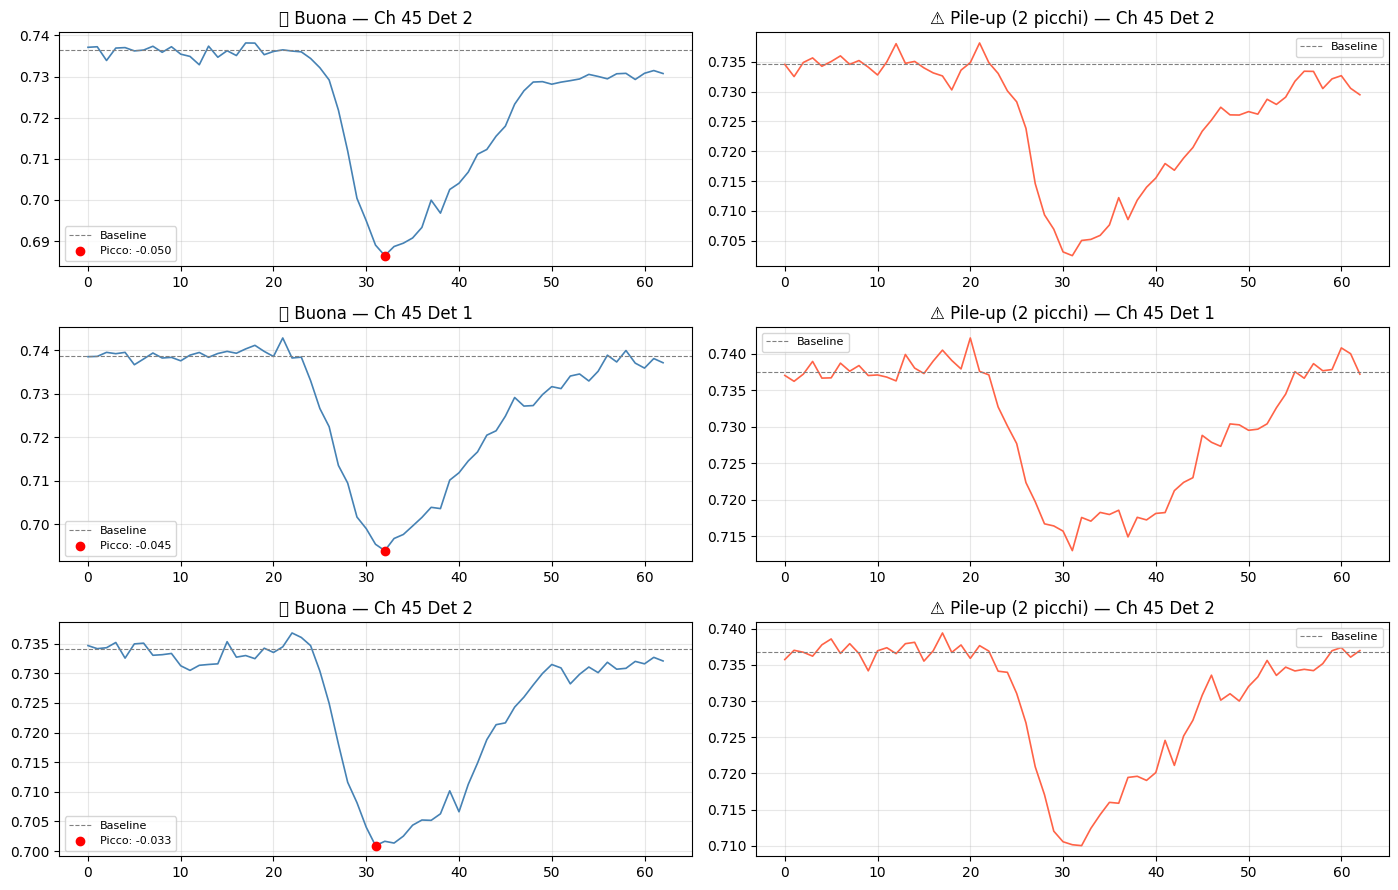

In [37]:
def plot_confronto(df_buoni, df_pileup, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(14, 3*n))

    for row in range(n):
        # --- Buona ---
        riga_b = df_buoni.iloc[row]
        wf_b   = riga_b['Waveform']
        axes[row, 0].plot(wf_b, color='steelblue', lw=1.2)
        axes[row, 0].axhline(float(riga_b['baseline']), color='gray', linestyle='--', lw=0.8, label='Baseline')
        axes[row, 0].scatter(int(riga_b['idx_picco']), wf_b[int(riga_b['idx_picco'])],
                             color='red', zorder=5, label=f"Picco: {float(riga_b['ampiezza']):.3f}")
        axes[row, 0].set_title(f"✅ Buona — Ch {int(riga_b['Channel'])} Det {int(riga_b['Detector'])}")
        axes[row, 0].legend(fontsize=8)
        axes[row, 0].grid(True, alpha=0.3)

        # --- Pile-up ---
        riga_p = df_pileup.iloc[row]
        wf_p   = riga_p['Waveform']
        axes[row, 1].plot(wf_p, color='tomato', lw=1.2)
        axes[row, 1].axhline(float(riga_p['baseline']), color='gray', linestyle='--', lw=0.8, label='Baseline')
        axes[row, 1].set_title(f"⚠️ Pile-up ({int(riga_p['n_picchi'])} picchi) — Ch {int(riga_p['Channel'])} Det {int(riga_p['Detector'])}")
        axes[row, 1].legend(fontsize=8)
        axes[row, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_confronto(df_buoni, df_pileup, n=3)

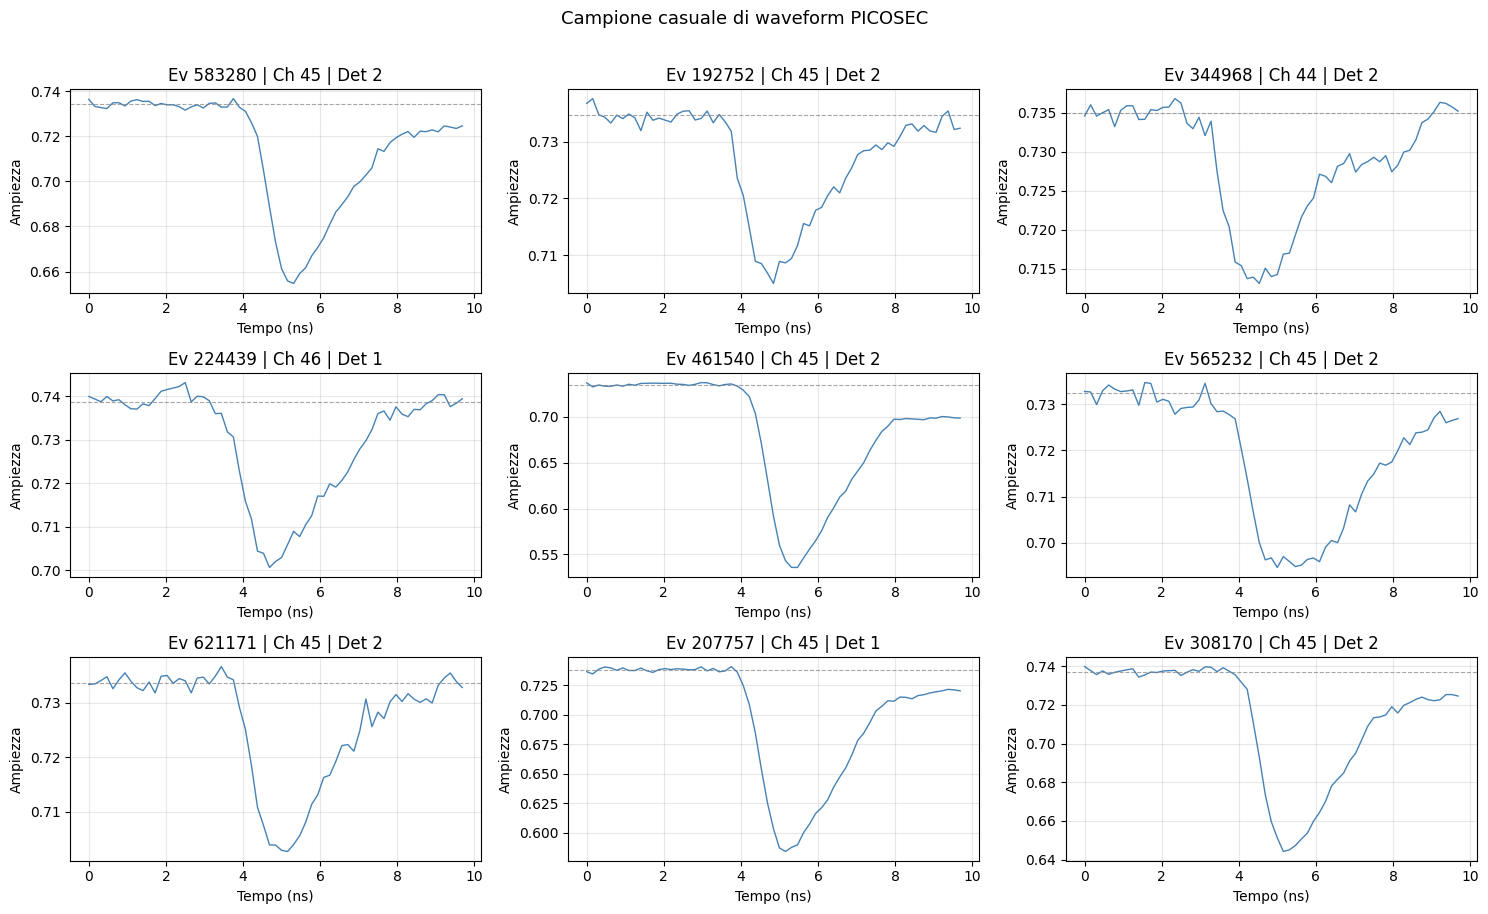

In [38]:
# algoritmo per pile up custom made
import matplotlib.pyplot as plt
import numpy as np

# Plotta 9 waveform a caso per farsi un'idea visiva
fig, axes = plt.subplots(3, 3, figsize=(15, 9))

# Campiona 9 righe casuali
sample = df.sample(9, random_state=42).reset_index(drop=True)

for idx, ax in enumerate(axes.flat):
    riga = sample.iloc[idx]
    wf   = riga['Waveform']
    t_ns = np.arange(len(wf)) * (1/6.4)  # converti sample → ns
    
    ax.plot(t_ns, wf, color='steelblue', lw=1)
    ax.axhline(float(riga['baseline']), color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.set_xlabel("Tempo (ns)")
    ax.set_ylabel("Ampiezza")
    ax.set_title(f"Ev {int(riga['event_idx'])} | Ch {int(riga['Channel'])} | Det {int(riga['Detector'])}")
    ax.grid(True, alpha=0.3)

plt.suptitle("Campione casuale di waveform PICOSEC", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [39]:
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

def is_pileup_picosec(wf, n_baseline=10, soglia_relativa=0.3, 
                       distance_samples=5, flat_top_samples=3):
    """
    Identifica pile-up in PICOSEC Micromegas con due criteri:
    
    1. DUE PICCHI VICINI: due minimi separati da almeno distance_samples
       (default=5 sample = ~780 ps a 6.4 GSa/s)
    
    2. FLAT TOP (massimo che persiste): la derivata vicino al picco 
       rimane quasi zero per più di flat_top_samples campioni
    
    Parametri:
    - soglia_relativa  : frazione dell'ampiezza per considerare un picco reale (default 0.3)
    - distance_samples : distanza minima tra due picchi in sample (default 5 ~ 780 ps)
    - flat_top_samples : quanti sample consecutivi vicino al picco per dire che è piatto
    """
    
    baseline = np.mean(wf[:n_baseline])
    wf_corr  = -(wf - baseline)  # inverti: minimi → massimi
    
    ampiezza_max = np.max(wf_corr)
    soglia       = soglia_relativa * ampiezza_max

    # --- Criterio 1: due picchi vicini ---
    picchi, props = find_peaks(wf_corr, height=soglia, distance=distance_samples)
    due_picchi = len(picchi) > 1

    # --- Criterio 2: flat top (picco che persiste) ---
    # Guarda la derivata nell'intorno del picco principale
    idx_picco  = np.argmax(wf_corr)
    
    # Finestra intorno al picco: ±flat_top_samples
    i_start = max(0, idx_picco - flat_top_samples)
    i_stop  = min(len(wf_corr), idx_picco + flat_top_samples)
    
    derivata  = np.abs(np.diff(wf_corr[i_start:i_stop]))
    soglia_dt = 0.05 * ampiezza_max  # derivata "piatta" = varia meno del 5% dell'ampiezza
    flat_top  = np.sum(derivata < soglia_dt) >= flat_top_samples

    pileup = due_picchi or flat_top

    return {
        'is_pileup'   : pileup,
        'due_picchi'  : due_picchi,
        'flat_top'    : flat_top,
        'n_picchi'    : len(picchi),
    }

# --- Applica a tutto il DataFrame ---
risultati = df['Waveform'].apply(is_pileup_picosec)
df['is_pileup']  = [r['is_pileup']  for r in risultati]
df['due_picchi'] = [r['due_picchi'] for r in risultati]
df['flat_top']   = [r['flat_top']   for r in risultati]
df['n_picchi']   = [r['n_picchi']   for r in risultati]

df_buoni  = df[~df['is_pileup']].reset_index(drop=True)
df_pileup = df[ df['is_pileup']].reset_index(drop=True)

# Quanti pile-up per ciascun criterio
n_due_picchi = df['due_picchi'].sum()
n_flat_top   = df['flat_top'].sum()

print(f"✅ Eventi buoni       : {len(df_buoni)}")
print(f"⚠️  Pile-up totali    : {len(df_pileup)}")
print(f"   di cui due picchi : {n_due_picchi}")
print(f"   di cui flat top   : {n_flat_top}")
print(f"📊 Frazione pile-up  : {len(df_pileup)/len(df)*100:.1f}%")

✅ Eventi buoni       : 323
⚠️  Pile-up totali    : 1334
   di cui due picchi : 725
   di cui flat top   : 894
📊 Frazione pile-up  : 80.5%


/tmp/ipykernel_13861/1440392335.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/riccardo-speziali/progetti_python/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


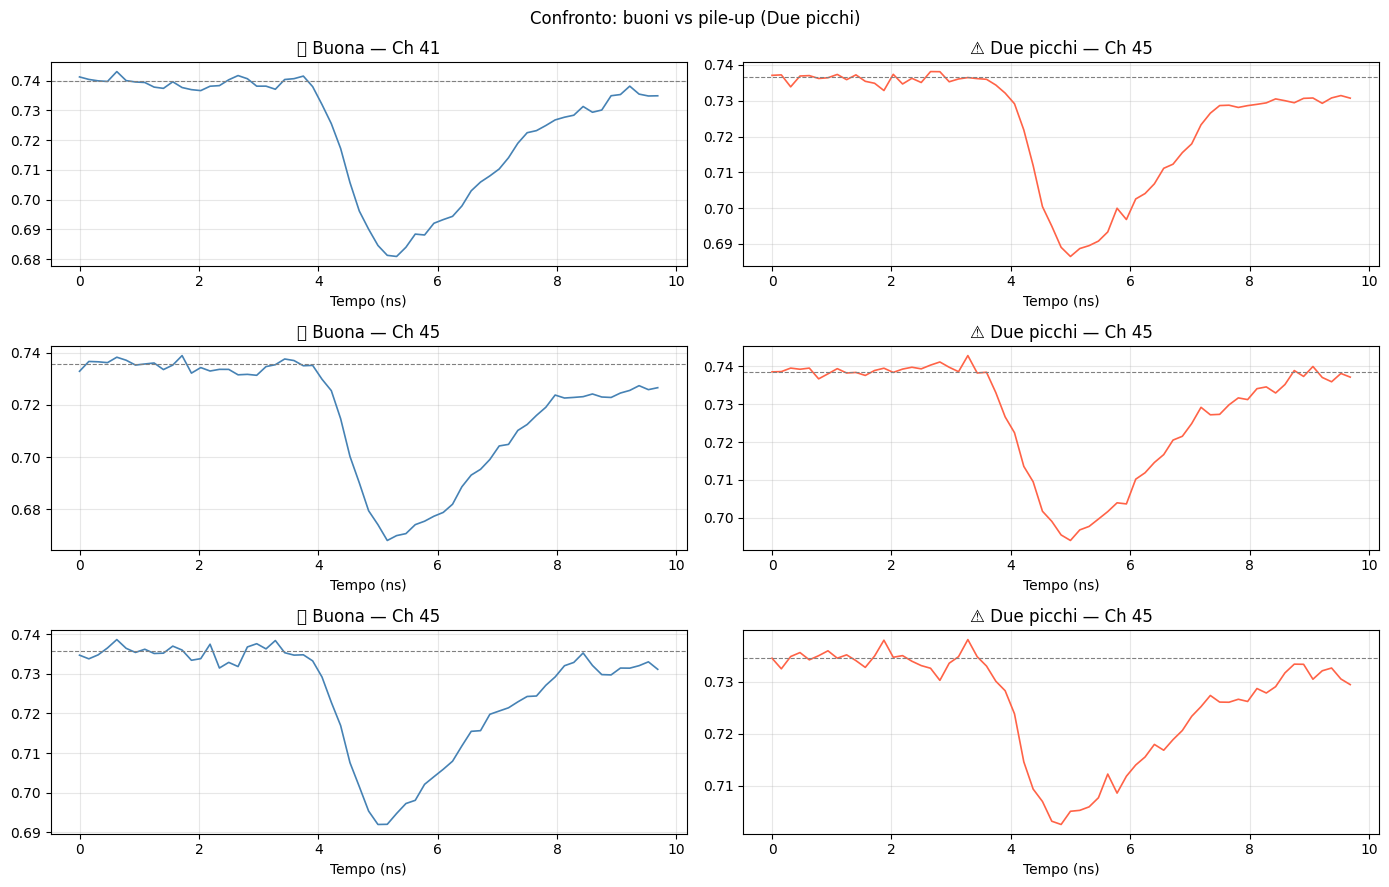

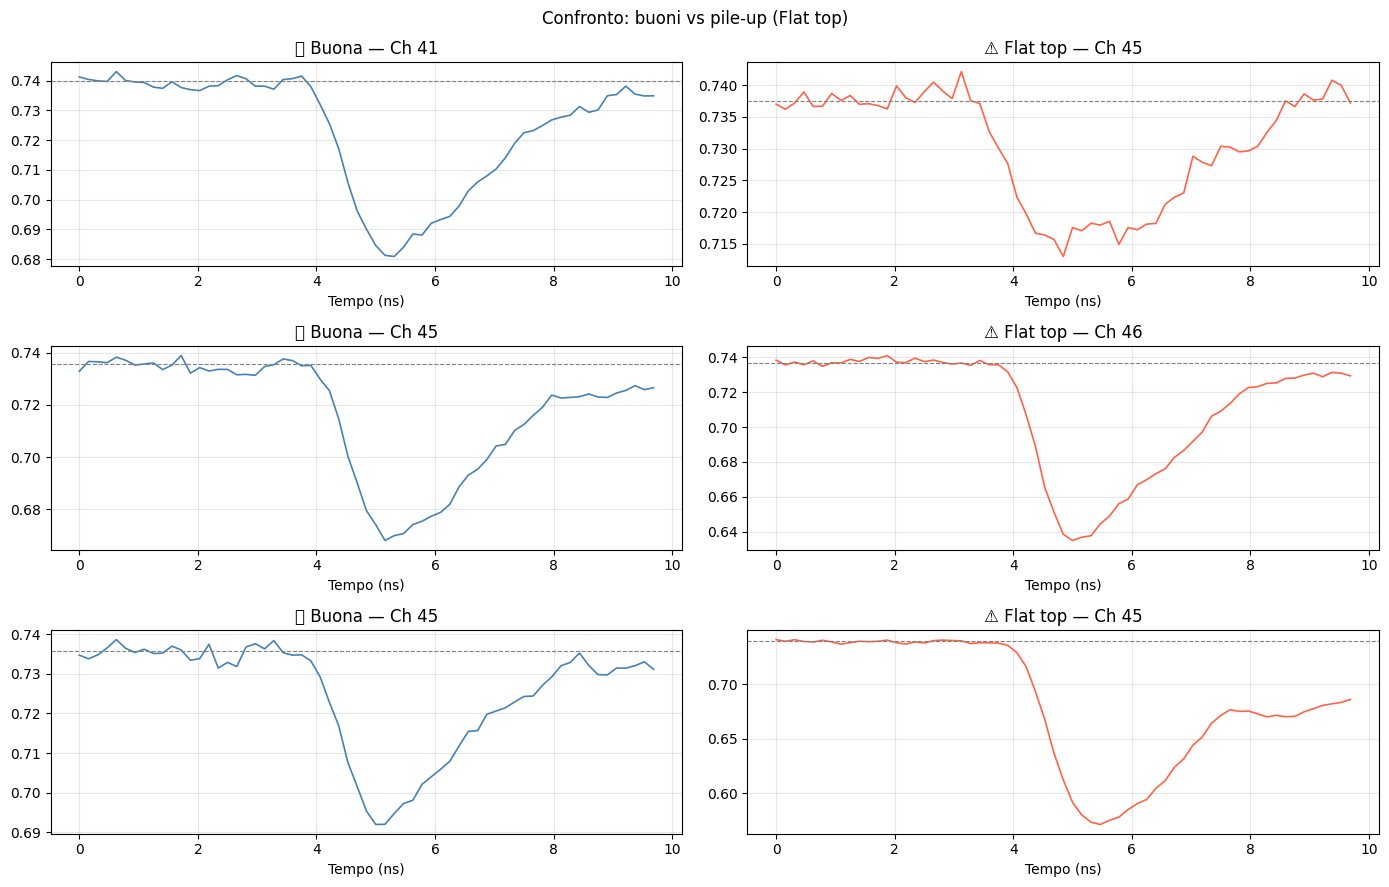

In [40]:
def plot_pileup_tipo(df_buoni, df_pileup, tipo='due_picchi', n=3):
    """
    tipo = 'due_picchi' o 'flat_top'
    """
    df_tipo = df_pileup[df_pileup[tipo]].reset_index(drop=True)
    
    fig, axes = plt.subplots(n, 2, figsize=(14, 3*n))
    label = "Due picchi" if tipo == 'due_picchi' else "Flat top"

    for row in range(min(n, len(df_tipo))):
        t_ns = np.arange(len(df_buoni.iloc[row]['Waveform'])) * (1/6.4)

        # Buona
        riga_b = df_buoni.iloc[row]
        axes[row, 0].plot(t_ns, riga_b['Waveform'], color='steelblue', lw=1.2)
        axes[row, 0].axhline(float(riga_b['baseline']), color='gray', linestyle='--', lw=0.8)
        axes[row, 0].set_title(f"✅ Buona — Ch {int(riga_b['Channel'])}")
        axes[row, 0].set_xlabel("Tempo (ns)")
        axes[row, 0].grid(True, alpha=0.3)

        # Pile-up del tipo scelto
        riga_p = df_tipo.iloc[row]
        t_ns_p = np.arange(len(riga_p['Waveform'])) * (1/6.4)
        axes[row, 1].plot(t_ns_p, riga_p['Waveform'], color='tomato', lw=1.2)
        axes[row, 1].axhline(float(riga_p['baseline']), color='gray', linestyle='--', lw=0.8)
        axes[row, 1].set_title(f"⚠️ {label} — Ch {int(riga_p['Channel'])}")
        axes[row, 1].set_xlabel("Tempo (ns)")
        axes[row, 1].grid(True, alpha=0.3)

    plt.suptitle(f"Confronto: buoni vs pile-up ({label})", fontsize=12)
    plt.tight_layout()
    plt.show()

# Visualizza i due tipi separatamente
plot_pileup_tipo(df_buoni, df_pileup, tipo='due_picchi', n=3)
plot_pileup_tipo(df_buoni, df_pileup, tipo='flat_top',   n=3)